# Lap-Rep (Laplacian Representation)

In [2]:
from neuronav.envs.grid_env import GridEnv, GridSize, GridObsType, GridTopography
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import torch
import torch.nn as nn

/Users/awjuliani/miniconda3/lib/python3.8/site-packages/matplotlib_inline/config.py:66: DeprecationWarning: InlineBackend._figure_formats_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_formats_changed(self, name, old, new):


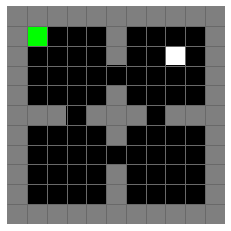

In [29]:
env = GridEnv(obs_type=GridObsType.twohot, topography=GridTopography.four_rooms, grid_size=GridSize.small)
obs = env.reset(random_start=True)
env.render()

In [30]:
def collect_steps(num_steps, num_eps):
    obs_pairs = []
    locations = []
    for j in range(num_eps):
        obs = env.reset(random_start=True)
        for i in range(num_steps):
            locations.append(env.agent_pos)
            new_obs, _, _, _ = env.step(env.action_space.sample())
            obs_pairs.append(np.array([obs, new_obs]))
            obs = new_obs
    obs_pairs = torch.tensor(np.stack(obs_pairs)).type(torch.float32)
    return obs_pairs, np.array(locations)

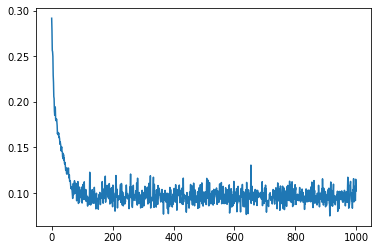

In [31]:
num_epoch = 1000
agent_steps = 6
agent_episodes = 40

embed_size = 16
h_size = 128

rand_proj = nn.Sequential(
    nn.Linear(env.observation_space.shape[0], h_size), 
    nn.Tanh(),
)

lap_map = nn.Sequential(
    nn.Linear(h_size, h_size),
    nn.GELU(),
    nn.Linear(h_size, h_size),
    nn.GELU(),
    nn.Linear(h_size, embed_size),
)

def nn_pass(x):
    h = rand_proj(x)
    h = h * 10
    return lap_map(h)

optimizer = torch.optim.Adam(lap_map.parameters(), lr=2e-4)

losses = []
for i in range(num_epoch):
    optimizer.zero_grad()
    obs, _ = collect_steps(agent_steps, agent_episodes)
    embed = nn_pass(obs)
    a = embed[:,0]
    b = embed[:,1]
    s_a = a[torch.randperm(a.size()[0])]
    s_b = b[torch.randperm(b.size()[0])]

    attract_term = torch.linalg.norm(a - b, dim=-1).pow(2)
    repel_term = torch.exp(-torch.linalg.norm(s_a - s_b, dim=-1))
    loss = attract_term.mean() + 0.2 * repel_term.mean()
    losses.append(loss.detach())
    loss.backward()
    optimizer.step()
plt.plot(losses)

Text(0.5, 1.0, 'Euclidean structure')

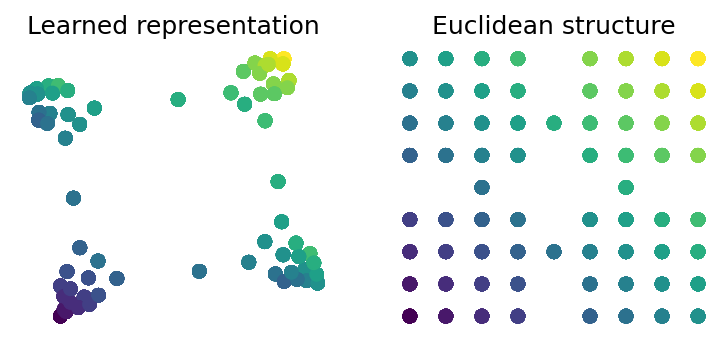

In [32]:
obs, locs = collect_steps(100, 50)
locs_n = np.array(locs) / (env.grid_size - 1)
scale = locs_n.sum(axis=-1) / 2
embed = nn_pass(obs)
a = embed[:,0].detach()
pca = PCA(n_components=2)
z = pca.fit_transform(a)

fig, axs = plt.subplots(1, 2, figsize=(6, 2.5), dpi=150)
axs[0].scatter(z[:,0], z[:,1], c=scale)
_ = axs[0].axis("off")
axs[0].set_title("Learned representation")
axs[1].scatter(locs_n[:,0], locs_n[:,1], c=scale)
_ = axs[1].axis("off")
axs[1].set_title("Euclidean structure")